# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [3]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [5]:
tracks = pd.read_parquet('data/tracks.parquet')
catalog_names = pd.read_parquet('data/catalog_names.parquet')
interactions = pd.read_parquet('data/interactions.parquet')

FileNotFoundError: [Errno 2] No such file or directory: 'data/tracks.parquet'

In [4]:
# Для удобства переименуем колонки
tracks.rename(columns={
    'albums': 'album',
    'genres': 'genre',
    'artists': 'artist'}, inplace=True)

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

tracks

In [5]:
tracks.sample(8).T

,461590,235661,1453,462526,938047,757144,812052,644346
track_id,32188696,13510067,7291,32236673,82358613,57867352,63912429,45263949
album,[3918348],"[1182260, 1469196]","[756, 677384, 7068096, 7677551, 9574570]",[3925305],[15374348],[8734161],[10212406],[6076577]
artist,[3999504],[130155],[682418],[98462],[8880726],[662347],[5080712],[4071698]
genre,"[47, 308]","[11, 37]",[68],[13],[68],[11],[27],"[44, 75]"


In [6]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   album     1000000 non-null  object
 2   artist    1000000 non-null  object
 3   genre     1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [7]:
print('Описательная статистика')
tracks.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
track_id,1000000.0,3.685121e+07,2.679771e+07,26.0,15430882.75,34550465.5,56925570.75,101521819.0


In [8]:
print('Незаполненные значения')
pd.DataFrame(tracks.isnull().sum()).T

Незаполненные значения


,track_id,album,artist,genre
0,0,0,0,0


In [9]:
# Проверим заполненность имён
tracks_ids = set(tracks['track_id'].unique())
tracks_names = set(catalog_names.query('type == "track"')['id'].unique())
logging.info(f'Количество "track" без имени: {len(tracks_ids - tracks_names)}')

def count_nameless_prop(prop: str):
    '''Рассчитывает количество безымянных значений свойства "prop"'''
    ids_count = set(tracks[[prop]].explode(prop, ignore_index=True)[prop].unique())
    names_count = set(catalog_names.query('type == @prop')['id'].unique())
    logging.info(f'Количество "{prop}" без имени: {len(ids_count - names_count)}')

count_nameless_prop('album')
count_nameless_prop('genre')
count_nameless_prop('artist')

Количество "track" без имени: 0
Количество "album" без имени: 1
Количество "genre" без имени: 31
Количество "artist" без имени: 1


In [10]:
def max_len_prop(prop: str):
    '''Рассчитывает максимальную длину свойства "prop"'''
    max_len = tracks[['track_id', prop]].explode(prop) \
        .groupby(['track_id']).agg(len=(prop, 'count')).reset_index()['len'].max()
    
    logging.info(f'Максимальная длина свойства "{prop}": {max_len}')

max_len_prop('album')
max_len_prop('genre')
max_len_prop('artist')

Максимальная длина свойства "album": 2844
Максимальная длина свойства "genre": 10
Максимальная длина свойства "artist": 26


In [11]:
# Вычислим количество дубликатов для свойства
def duplicate_count_prop(prop: str):
    '''Рассчитывает количество дубликатов свойства "prop"'''
    duplicate_count = tracks.explode(prop)[['track_id', prop]] \
        .merge(catalog_names.query('type == @prop'), left_on=prop, right_on='id')[['track_id', 'name', 'id']] \
        .groupby(['track_id', 'name']).agg(count=('id', 'count')).reset_index() \
        .query('count > 1') \
        ['name'].nunique()
        
    logging.info(f'Количество дубликатов свойства "{prop}": {duplicate_count}')
        
duplicate_count_prop('album')
duplicate_count_prop('genre')
duplicate_count_prop('artist')         

Количество дубликатов свойства "album": 47868
Количество дубликатов свойства "genre": 0
Количество дубликатов свойства "artist": 43


catalog_names

In [12]:
catalog_names.sample(8).T

,664324,775428,965849,684137,1320001,496789,1293015,1588493
id,32964,6257518,3854759,331689,35186194,10991125,33219923,59868787
type,artist,artist,track,artist,track,album,track,track
name,Craig David,Meditat1on,Как много девушек хороших,Amir Jamal,Carnation,SEVENTH HEAVEN,Сен Де Мен Де,Dangerous Days


In [13]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [14]:
print('Описательная статистика')
catalog_names.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
id,1812471.0,2.321647e+07,2.526044e+07,0.0,3480524.0,12114360.0,37738170.0,101521819.0


In [15]:
print('Незаполненные значения')
pd.DataFrame(catalog_names.isnull().sum()).T

Незаполненные значения


,id,type,name
0,0,0,0


In [16]:
print('Уникальные значения свойства "type"')
pd.DataFrame(catalog_names["type"].value_counts()).T

Уникальные значения свойства "type"


type,track,album,artist,genre
count,1000000,658724,153581,166


interactions

In [17]:
interactions.sample(8).T

,209,193,163,43,495,178,166,484
user_id,1272534,897433,1198088,726734,137448,989853,1269686,262208
track_id,60905506,78453106,2469563,148092,34526178,73845405,79802535,85407850
track_seq,210,194,164,44,496,179,167,485
started_at,2022-09-16 00:00:00,2022-10-06 00:00:00,2022-08-19 00:00:00,2022-07-14 00:00:00,2022-10-08 00:00:00,2022-12-19 00:00:00,2022-12-09 00:00:00,2022-12-20 00:00:00


In [18]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [19]:
print('Описательная статистика')
interactions.describe().T

Описательная статистика


,count,mean,min,25%,50%,75%,max,std
user_id,222629898.0,687576.660624,0.0,343371.0,687973.0,1031127.0,1374582.0,396903.293288
track_id,222629898.0,36536224.961649,26.0,14808489.0,35524737.0,56511373.0,101521819.0,26617816.837147
track_seq,222629898.0,462.140293,1.0,56.0,181.0,506.0,16637.0,825.731213
started_at,222629898,2022-08-29 16:39:44.541336320,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-09-15 00:00:00,2022-11-09 00:00:00,2022-12-31 00:00:00,NaN


In [20]:
print('Незаполненные значения')    
pd.DataFrame(interactions.isnull().sum()).T

Незаполненные значения


,user_id,track_id,track_seq,started_at
0,0,0,0,0


In [21]:
logging.info(f'Количество уникальных пользователей:{interactions["user_id"].nunique()}')

Количество уникальных пользователей:1373221


# Выводы

Приведём выводы по первому знакомству с данными:
- Количество "track" без имени: 0
- Количество "album" без имени: 1
- Количество "genre" без имени: 31
- Количество "artist" без имени: 1
- Максимальная длина свойства "album": 2844
- Максимальная длина свойства "genre": 10
- Максимальная длина свойства "artist": 26
- Количество дубликатов свойства "album": 47868
- Количество дубликатов свойства "genre": 0
- Количество дубликатов свойства "artist": 43

Коррекирующие действия выполнены ниже

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

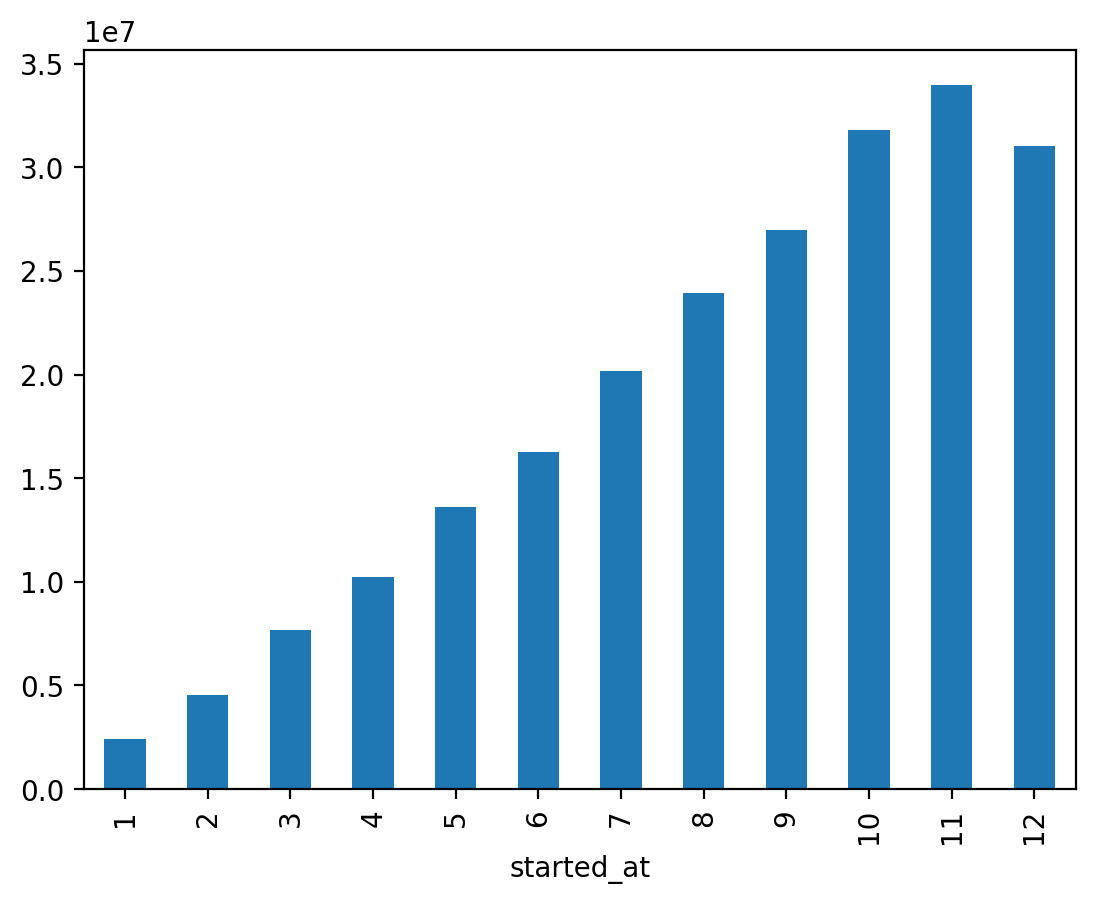

In [22]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [23]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .sort_values('votes', ascending=False).head(10) \
    .merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='left')[['name', 'votes']] \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,Smells Like Teen Spirit,111062
2,Believer,106921
3,Numb,101924
4,I Got Love,99490
5,Юность,86670
6,Way Down We Go,86246
7,Shape of You,85886
8,In The End,85244
9,Shape Of My Heart,85042
10,Life,84748


Наиболее популярные жанры

In [2]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .merge(tracks, on='track_id', how='left')[['votes', 'genre']] \
    .explode('genre') \
    .merge(catalog_names.query('type == "genre"'), left_on='genre', right_on='id', how='left')[['name', 'votes']] \
    .groupby('name').agg(votes=('votes', 'sum')).reset_index() \
    .sort_values('votes', ascending=False) \
    .head(10).set_index([pd.Index(range(1, 11))])

NameError: name 'interactions' is not defined

Треки, которые никто не прослушал

In [25]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,album,artist,genre


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [26]:
# Удалим треки с пустыми свойствами
tracks_empty = tracks.apply(lambda x: len(x['album']) == 0 or len(x['artist']) == 0 or len(x['genre']) == 0, axis=1)
tracks = tracks[~tracks_empty]
# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

logging.info(f'Удалены треки, у которых не заполнены свойства в количестве: {tracks_empty.sum()}')

del tracks_empty

Удалены треки, у которых не заполнены свойства в количестве: 19023


In [27]:
# Рассчитаем количество прослушиваний
tracks = tracks.merge(interactions.groupby(['track_id']).agg(votes=('user_id', 'count')), on='track_id')

In [28]:
# Получим имена треков и удалим безымянные
df_track = tracks.merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='inner') \
    .reset_index()[['track_id', 'type', 'name', 'votes']]
    
# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(df_track['track_id'].unique())]  

In [29]:
def explode_prop(prop: str):
    '''Разворачивает свойство "prop"'''
    df = tracks.explode(prop)[['track_id', prop, 'votes']] \
        .rename(columns={prop: 'id', 'votes': 'votes_single'}) \
        .merge(catalog_names.query(f'type == "{prop}"'), on='id', how='inner') \
    
    votes = df.groupby(['track_id', 'name']).agg(votes=('votes_single', 'sum'))
    df = df.merge(votes, on=['track_id', 'name'])
    
    df['rank'] = df.groupby(['track_id', 'name']).cumcount() + 1
    
    return df.query('rank == 1')[['track_id', 'type', 'id', 'name', 'votes']]  


df_album = explode_prop('album')
df_artist = explode_prop('artist')
df_genre = explode_prop('genre')

In [30]:
def calc_rating(votes: np.array, base: int = 10):
    '''Расчитывает рейтинг'''
    pow_votes = np.emath.logn(base, np.max(votes)) 
    return np.power(votes, 1/pow_votes).round(2)


def calc_rating_prop(df: pd.DataFrame):
    '''Расчитывает рейтинг набора'''
    df = df.rename(columns={'votes': 'votes_single'})
        
    votes = df.groupby(['id']).agg(votes=('votes_single', 'sum')).reset_index()
    votes['rating'] = calc_rating(votes['votes'])
    
    df = df.merge(votes, on='id') \
        .drop('votes_single', axis=1) \
        .sort_values(by='rating', ascending=False)

    return df


df_track['rating'] = calc_rating(df_track['votes'].values)
df_album = calc_rating_prop(df_album)
df_artist = calc_rating_prop(df_artist)
df_genre = calc_rating_prop(df_genre)

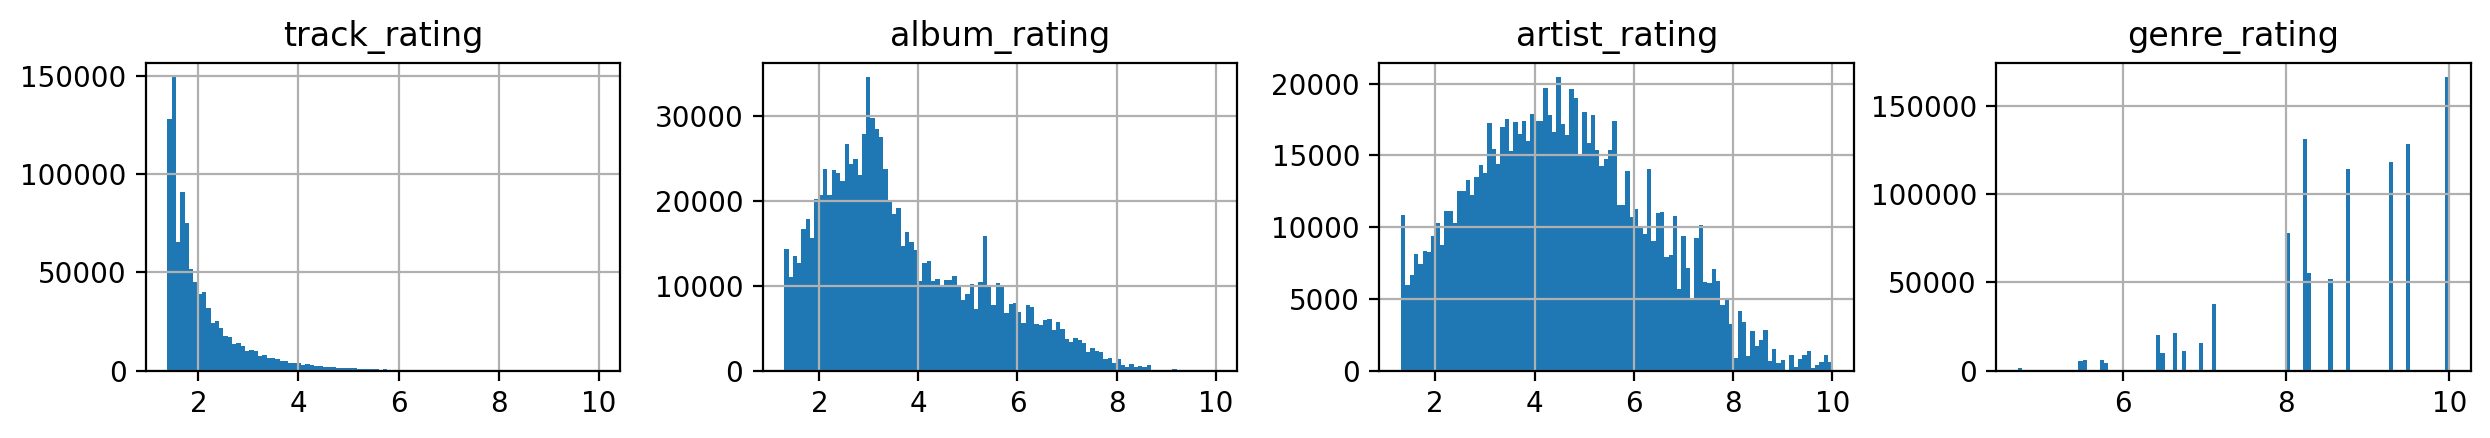

In [31]:
# Распределение рейтингов
df_ratings = pd.DataFrame()

df_ratings['track_rating'] = df_track['rating']
df_ratings['album_rating'] = df_album['rating']
df_ratings['artist_rating'] = df_artist['rating']
df_ratings['genre_rating'] = df_genre['rating']

df_ratings.hist(bins=100, layout=(1, 4), figsize=(15, 2))

del df_ratings

In [32]:
# Сформируем развернутую таблицу треков
tracks_exploded = pd.concat([
    df_track,
    df_album,
    df_artist,
    df_genre
]).fillna(-1)

del df_track, df_album, df_artist, df_genre

In [33]:
def prop_agg(data: pd.DataFrame, prop: str):
    '''Рассчитывает агрегированные знайения свойства "prop"'''
    df_agg = data.query('type == @prop').groupby(['track_id']) \
        .agg(count=('id', 'count'), rating_mean=('rating', 'mean'), votes_mean=('votes', 'mean')) \
        .reset_index()
    
    for col in df_agg.columns:
        if col == 'track_id':
            continue
        df_agg[col] = df_agg[col].round(2)
    
    arr_agg = []
    for _, row in df_agg.iterrows():
        agg = {}
        for col in df_agg.columns:
            if col == 'track_id':
                continue
            agg[col] = row[col]
        arr_agg.append(str(agg))
    
    df_agg[f'agg_{prop}'] = arr_agg
    return df_agg[['track_id', f'agg_{prop}']]

tracks_agg = pd.DataFrame(data=tracks_exploded['track_id'].unique(), columns=['track_id'])
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'genre'), on='track_id')
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'album'), on='track_id')
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'artist'), on='track_id')

In [34]:
# Удалим не популярные треки
tracks = tracks.query('votes >= 1000')
tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(tracks['track_id'].unique())]
tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

In [35]:
# Оставим по 5 самых популярных значений свойств трека
tracks_exploded['rank'] = tracks_exploded.groupby(['track_id', 'type']).cumcount(ascending=True) + 1
tracks_exploded = tracks_exploded.query('rank <= 5')

In [36]:
# Удалим лишние взаимодействия

# Рассчитаем показатели пользвателей
users_agg = interactions.groupby('user_id').agg(events_count=('track_id', 'count'))
interactions = interactions.merge(users_agg, on='user_id', how='left')

# Удалим пользвателей, у которых менее 10 взаимодействий
interactions = interactions.query('events_count > 11')

# Оставим 10 последних взаимодействий для каждого пользователя
interactions['rank'] = interactions.groupby('user_id').cumcount(ascending=False) + 1
interactions = interactions.query('rank <= 10')

# Оставим только актуальные треки
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]
tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(interactions['track_id'].unique())]
tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

del users_agg

In [37]:
# Преобразуем треки в удобный формат
tracks_arr = []

for _, data in tracks_exploded.groupby('track_id'):
    
    new_row = {
        'track_id': data.iloc[0, data.columns.get_loc('track_id')],
        'track': None,
        'votes': None,
        'rating': None,
        'genre': None,
        'album': None,
        'artist': None
    }
    
    for row in data.itertuples():
        if row.type == 'track':
            new_row['track'] = row.name
            new_row['votes'] = row.votes
            new_row['rating'] = row.rating
            continue
        
        if new_row[row.type] is None:
            new_row[row.type] = {}
        
        value = {
            'name': row.name,
            'votes': row.votes,
            'rating': row.rating
        }
        
        new_row[row.type][row.id] = value
    
    tracks_arr.append(new_row)
    
tracks = pd.DataFrame(tracks_arr)
tracks['genre'] = tracks['genre'].astype('str')
tracks['album'] = tracks['album'].astype('str')
tracks['artist'] = tracks['artist'].astype('str')

del tracks_exploded

In [39]:
# Добавим трекам агрегированные данные
tracks = tracks.merge(tracks_agg, on='track_id')

del tracks_agg

In [27]:
tracks.sample(5)

NameError: name 'tracks' is not defined

In [40]:
# Добавим взаимодействиям рейтинги треков
interactions = interactions.merge(tracks[['track_id', 'votes', 'rating']], on='track_id', how='left')

In [ ]:
interactions.sample(5)

In [41]:
interactions.shape, tracks.shape

((11607560, 8), (39365, 10))

# EDA преобразованных данных

Распределение количества прослушанных треков.

In [ ]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [ ]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .sort_values('votes', ascending=False).head(10) \
    .merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='left')[['name', 'votes']] \
    .set_index([pd.Index(range(1, 11))])

Наиболее популярные жанры

In [ ]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .merge(tracks, on='track_id', how='left')[['votes', 'genre']] \
    .explode('genre') \
    .merge(catalog_names.query('type == "genre"'), left_on='genre', right_on='id', how='left')[['name', 'votes']] \
    .groupby('name').agg(votes=('votes', 'sum')).reset_index() \
    .sort_values('votes', ascending=False) \
    .head(10).set_index([pd.Index(range(1, 11))])

Треки, которые никто не прослушал

In [ ]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [42]:
tracks.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions.rename(columns={'track_id': 'item_id'}, inplace=True)

tracks.to_parquet('data/items.parquet')
interactions.to_parquet('data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [43]:
del tracks
del interactions
del catalog_names

In [1]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
items = pd.read_parquet('data/items.parquet')
events = pd.read_parquet('data/events.parquet')

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

<Axes: xlabel='started_at'>

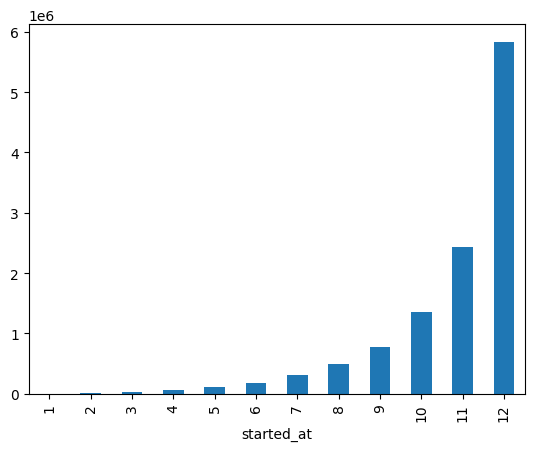

In [3]:
events['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

In [11]:
train_split_date = pd.to_datetime('2022-12-16').to_datetime64()

train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

events_train.shape, events_test.shape

((7883316, 8), (3724244, 8))

In [13]:
events_train.sort_values('started_at')

,user_id,item_id,track_seq,started_at,events_count,rank,votes,rating
2687650,318423,582507,3,2022-01-02,12,10,47143,8.44
9192720,1088742,109641,3,2022-01-03,12,10,9569,6.15
8649720,1024483,66991689,11,2022-01-04,19,10,6875,5.76
6351800,752143,24199682,11,2022-01-04,19,10,1659,4.35
8649721,1024483,68686971,12,2022-01-04,19,9,2627,4.76
...,...,...,...,...,...,...,...,...
3437214,407450,70645322,161,2022-12-15,105,6,2707,4.79
4148066,491587,81838301,51,2022-12-15,51,4,26168,7.51
8944647,1059301,77491330,211,2022-12-15,210,3,6087,5.62
7249613,858628,58389862,252,2022-12-15,182,7,4995,5.41


In [6]:
# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

len(users_train), len(users_test), len(common_users)

(1105245, 331398, 275887)

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [50]:
from surprise import Dataset, Reader
from surprise import SVD

# используем Reader из библиотеки surprise для преобразования событий (events)
# в формат, необходимый surprise
reader = Reader(rating_scale=(1, 10))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set) 

In [51]:
surprise_test_set = list(events_test[['user_id', 'item_id', 'rating']].itertuples(index=False))

# получаем рекомендации для тестовой выборки
svd_predictions = svd_model.test(surprise_test_set) 

Анализ результатов

In [53]:
df_svd_predictions = pd.DataFrame(svd_predictions)
df_svd_predictions = df_svd_predictions.merge(items, left_on='iid', right_on='item_id', how='left')
df_svd_predictions['est2rating'] = df_svd_predictions['est'] / df_svd_predictions['rating']

In [56]:
df_svd_predictions.describe()

,uid,iid,r_ui,est,item_id,votes,rating,est2rating
count,1.304165e+06,1.304165e+06,1.304165e+06,1.304165e+06,1.304165e+06,1.304165e+06,1.304165e+06,1.304165e+06
mean,6.864373e+05,7.138353e+07,5.784219e+00,5.800834e+00,7.138353e+07,1.178640e+04,5.784219e+00,1.004511e+00
std,3.972784e+05,2.321724e+07,1.337451e+00,1.300398e+00,2.321724e+07,1.535221e+04,1.337451e+00,1.249594e-02
min,4.000000e+00,1.886000e+04,3.930000e+00,3.648070e+00,1.886000e+04,1.000000e+03,3.930000e+00,8.661845e-01
25%,3.426510e+05,5.483372e+07,4.690000e+00,4.736448e+00,5.483372e+07,2.429000e+03,4.690000e+00,9.976344e-01
50%,6.848940e+05,7.819500e+07,5.510000e+00,5.532257e+00,7.819500e+07,5.503000e+03,5.510000e+00,1.002582e+00
75%,1.032088e+06,9.163340e+07,6.700000e+00,6.685264e+00,9.163340e+07,1.469000e+04,6.700000e+00,1.008903e+00
max,1.374582e+06,1.010163e+08,1.000000e+01,9.954094e+00,1.010163e+08,1.110620e+05,1.000000e+01,1.489458e+00


In [62]:
df_svd_predictions[['est', 'rating', 'est2rating']].round(3).sample(8).T

,226903,981575,359566,1156639,1154512,1108224,95973,605729
est,6.258,9.161,4.450,4.421,4.067,4.816,7.538,5.084
rating,6.280,9.230,4.470,4.400,4.030,4.770,7.630,5.070
est2rating,0.996,0.992,0.996,1.005,1.009,1.010,0.988,1.003


In [65]:
df_svd_predictions.query('uid == 1374582').sort_values(by='est', ascending=False)

,uid,iid,r_ui,est,details,item_id,track,votes,rating,genre,album,artist,agg_genre,agg_album,agg_artist,est2rating
1304156,1374582,93126179,8.75,8.694153,{'was_impossible': False},93126179,Солнце Монако,56577,8.75,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...","{18729695: {'name': 'The End', 'votes': 60285,...","{4664209: {'name': 'Люся Чеботина', 'votes': 1...","{'count': 2.0, 'rating_mean': 9.54, 'votes_mea...","{'count': 1.0, 'rating_mean': 5.7, 'votes_mean...","{'count': 1.0, 'rating_mean': 7.34, 'votes_mea...",0.993617
1304159,1374582,94848971,6.56,6.551555,{'was_impossible': False},94848971,"Боже, как завидую",13188,6.56,"{75: {'name': 'rap', 'votes': 37799821, 'ratin...","{19278807: {'name': 'Боже, как завидую', 'vote...","{5129397: {'name': 'HammAli & Navai', 'votes':...","{'count': 2.0, 'rating_mean': 9.27, 'votes_mea...","{'count': 1.0, 'rating_mean': 4.48, 'votes_mea...","{'count': 2.0, 'rating_mean': 9.11, 'votes_mea...",0.998713
1304155,1374582,92448465,5.93,5.934491,{'was_impossible': False},92448465,Стеклянная 2,7942,5.93,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...","{18524268: {'name': 'Стеклянная 2', 'votes': 7...","{3304163: {'name': 'Лёша Свик', 'votes': 26657...","{'count': 2.0, 'rating_mean': 9.54, 'votes_mea...","{'count': 1.0, 'rating_mean': 4.14, 'votes_mea...","{'count': 2.0, 'rating_mean': 7.18, 'votes_mea...",1.000757
1304162,1374582,97241171,5.55,5.565580,{'was_impossible': False},97241171,UP,5701,5.55,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...","{20010065: {'name': 'UP', 'votes': 5701, 'rati...","{170642: {'name': 'INNA', 'votes': 175037, 'ra...","{'count': 1.0, 'rating_mean': 10.0, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.93, 'votes_mea...","{'count': 2.0, 'rating_mean': 7.58, 'votes_mea...",1.002807
1304160,1374582,94960284,5.14,5.168372,{'was_impossible': False},94960284,Есть че вспомнить,3863,5.14,"{75: {'name': 'rap', 'votes': 37799821, 'ratin...","{19316618: {'name': 'Есть че вспомнить', 'vote...","{158454: {'name': 'GUF', 'votes': 369079, 'rat...","{'count': 2.0, 'rating_mean': 9.27, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.69, 'votes_mea...","{'count': 2.0, 'rating_mean': 7.64, 'votes_mea...",1.005520
1304163,1374582,98542641,4.98,5.008560,{'was_impossible': False},98542641,Ameno Amapiano Remix (You Wanna Bamba),3293,4.98,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...",{20477408: {'name': 'Ameno Amapiano Remix (You...,"{7892984: {'name': 'Nektunez', 'votes': 3744, ...","{'count': 1.0, 'rating_mean': 10.0, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.6, 'votes_mean...","{'count': 2.0, 'rating_mean': 3.97, 'votes_mea...",1.005735
1304161,1374582,97220301,4.87,4.902997,{'was_impossible': False},97220301,Squid Game (Let's Play),2950,4.87,"{16: {'name': 'dance', 'votes': 16291557, 'rat...","{20002121: {'name': ""Squid Game (Let's Play)"",...","{1033565: {'name': 'Alok', 'votes': 108038, 'r...","{'count': 1.0, 'rating_mean': 8.53, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.95, 'votes_mea...","{'count': 1.0, 'rating_mean': 7.02, 'votes_mea...",1.006776
1304158,1374582,93838120,4.86,4.888340,{'was_impossible': False},93838120,Танцевали до утра,2915,4.86,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...","{18950998: {'name': 'Танцевали до утра', 'vote...","{3304163: {'name': 'Лёша Свик', 'votes': 26657...","{'count': 2.0, 'rating_mean': 9.54, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.53, 'votes_mea...","{'count': 1.0, 'rating_mean': 8.17, 'votes_mea...",1.005831
1304164,1374582,100736375,4.41,4.451772,{'was_impossible': False},100736375,Притяжение,1794,4.41,"{11: {'name': 'pop', 'votes': 55578305, 'ratin...","{21177040: {'name': 'Притяжение', 'votes': 179...","{10678610: {'name': 'ETOLUBOV', 'votes': 10144...","{'count': 2.0, 'rating_mean': 9.54, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.27, 'votes_mea...","{'count': 1.0, 'rating_mean': 4.72, 'votes_mea...",1.009472
1304157,1374582,93571683,4.24,4.290248,{'was_impossible': False},93571683,Меж

array([[<Axes: title={'center': 'est'}>,
        <Axes: title={'center': 'rating'}>,
        <Axes: title={'center': 'est2rating'}>]], dtype=object)

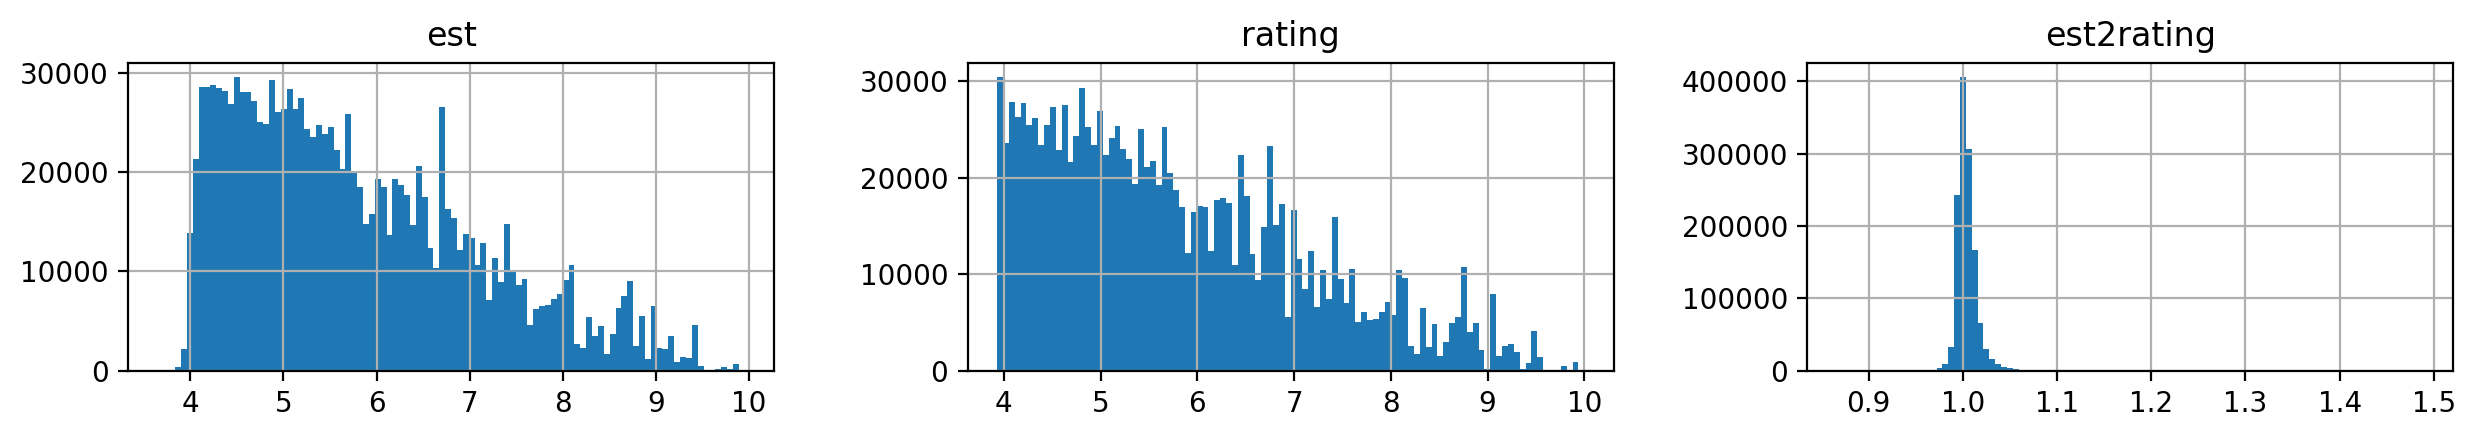

In [67]:
df_svd_predictions[['est', 'rating', 'est2rating']].hist(bins=100, layout=(1, 3), figsize=(15, 2))

Проверка метрик на адекватность

In [68]:
from surprise import NormalPredictor
from surprise import accuracy

# инициализируем состояние генератора, это необходимо для получения
# одной и той же последовательности случайных чисел, только в учебных целях
np.random.seed(0)

random_model = NormalPredictor()

random_model.fit(surprise_train_set)
random_predictions = random_model.test(surprise_test_set)

rmse = accuracy.rmse(random_predictions)
mae = accuracy.mae(random_predictions)

RMSE: 1.9272
MAE:  1.5489


In [69]:
from surprise import accuracy

rmse = accuracy.rmse(svd_predictions)
mae = accuracy.mae(svd_predictions)

RMSE: 0.0613
MAE:  0.0410


In [70]:
del df_svd_predictions

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [7]:
import scipy
import sklearn.preprocessing

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events['user_id'])
events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items['item_id'])
items['item_id_enc'] = item_encoder.transform(items['item_id'])
events_train['item_id_enc'] = item_encoder.transform(events_train['item_id'])
events_test['item_id_enc'] = item_encoder.transform(events_test['item_id'])

/tmp/ipykernel_3742/3586575175.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
/tmp/ipykernel_3742/3586575175.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])
/tmp/ipykernel_3742/3586575175.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [8]:
# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train['rating'],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8) 

In [9]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=10, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:31<00:00,  3.13s/it]


In [10]:
user_item_matrix_train.shape, len(user_encoder.classes_)

((1160755, 39365), 1160756)

In [11]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(user_item_matrix_train.shape[0])
# user_ids_encoded = range(len(user_encoder.classes_))
# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, N=100) 

In [12]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    'user_id_enc': user_ids_encoded,
    'item_id_enc': item_ids_enc.tolist(), 
    'score': als_scores.tolist()})
als_recommendations = als_recommendations.explode(['item_id_enc', 'score'], ignore_index=True)

# приводим типы данных
als_recommendations['item_id_enc'] = als_recommendations['item_id_enc'].astype('int')
als_recommendations['score'] = als_recommendations['score'].astype('float')

# получаем изначальные идентификаторы
als_recommendations['user_id'] = user_encoder.inverse_transform(als_recommendations['user_id_enc'])
als_recommendations['item_id'] = item_encoder.inverse_transform(als_recommendations['item_id_enc'])
als_recommendations = als_recommendations.drop(columns=['user_id_enc', 'item_id_enc']) 

In [16]:
als_recommendations.sample(8).T

,97869746,94453879,47296184,108307677,88314248,85114618,76799348,85274616
score,1.880649e-01,1.442748e-01,9.870876e-02,4.674415e-02,8.865595e-02,2.154713e-01,5.178591e-02,1.231649e-01
user_id,1.159400e+06,1.118696e+06,5.605060e+05,1.282721e+06,1.045929e+06,1.008047e+06,9.097420e+05,1.009896e+06
item_id,9.312618e+07,2.691847e+07,7.564296e+07,3.294800e+07,3.090441e+07,8.015354e+07,8.369821e+07,2.202062e+07


Анализ результатов

In [17]:
als_recommendations.shape, events_train.shape

((116075500, 3), (10303395, 10))

array([[<Axes: title={'center': 'score'}>]], dtype=object)

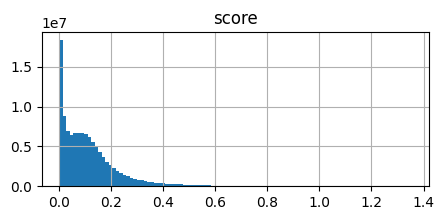

In [18]:
als_recommendations[['score']].hist(bins=100, figsize=(5, 2))

In [19]:
als_recommendations = (
    als_recommendations
    .merge(events[['user_id', 'item_id', 'rating']]
    .rename(columns={'rating': 'rating_test'}), 
    on=['user_id', 'item_id'], how='left')
) 

In [22]:
isnull_sum = als_recommendations['rating_test'].isnull().sum()
als_recommendations.shape[0], isnull_sum, als_recommendations.shape[0] - isnull_sum

(116075500, 113172448, 2903052)

In [23]:
als_recommendations.query('~rating_test.isnull()').sample(8)

,score,user_id,item_id,rating_test
46353461,0.111933,549269,93917350,5.57
84983767,0.092061,1006524,52122761,6.87
112374135,0.099484,1330715,96368212,6.08
29261513,0.267078,346740,95341975,6.21
19006607,0.201948,225161,98280795,6.73
22221100,0.847297,263311,65851540,9.52
90966066,0.162421,1077320,54014020,7.46
18536335,0.140298,219579,99668674,5.15


In [24]:
import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    ''' подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    '''
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg 

In [25]:
ndcg_at_5_scores = als_recommendations.query('~rating_test.isnull()') \
    .groupby('user_id').apply(lambda x: compute_ndcg(x['rating_test'], x['score'], k=5)) 

In [26]:
print('NDCG@5:', ndcg_at_5_scores.mean()) 

NDCG@5: 0.9956979681678826


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.